In [228]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [229]:
df=sns.load_dataset("iris")

In [230]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

df["species"]=encoder.fit_transform(df["species"])


In [231]:
X=df.drop("species",axis=1)
y=df["species"]

In [232]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
transformer=ColumnTransformer([
    ("scaler",StandardScaler(),X.columns)
])

In [233]:
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

pipeline=Pipeline([
    ("transformer",transformer),
    ("model",DecisionTreeClassifier())
])

param_grid = {
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_leaf": [1, 2, 4],
    "model__min_samples_split": [2, 5],
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__splitter": ["best", "random"],
    "model__max_features": [None, "sqrt", "log2", 0.3, 0.5, 0.7],
    "model__max_leaf_nodes": [None, 50, 100, 200, 500],
    "model__min_impurity_decrease": [0.0, 0.0001, 0.001, 0.01],
    "model__ccp_alpha": [0.0, 0.0001, 0.001, 0.005, 0.01],
    "model__class_weight": [None, "balanced"]
}

grid=GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    n_jobs=-1,
    scoring="accuracy"
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

best_model=grid.best_estimator_

y_pred=best_model.predict(X_test)

{'model__ccp_alpha': 0.005, 'model__class_weight': 'balanced', 'model__criterion': 'entropy', 'model__max_depth': None, 'model__max_features': 'log2', 'model__max_leaf_nodes': 200, 'model__min_impurity_decrease': 0.0001, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__splitter': 'random'}
0.9916666666666666


In [234]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9666666666666667
[[10  0  0]
 [ 0 12  1]
 [ 0  0  7]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.92      0.96        13
           2       0.88      1.00      0.93         7

    accuracy                           0.97        30
   macro avg       0.96      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



[Text(0.515625, 0.9545454545454546, 'x[3] <= 0.72\nentropy = 1.585\nsamples = 120\nvalue = [40.0, 40.0, 40.0]'),
 Text(0.15625, 0.8636363636363636, 'x[2] <= -1.071\nentropy = 1.254\nsamples = 81\nvalue = [40.0, 38.919, 4.651]'),
 Text(0.3359375, 0.9090909090909092, 'True  '),
 Text(0.09375, 0.7727272727272727, 'entropy = 0.0\nsamples = 39\nvalue = [39, 0, 0]'),
 Text(0.21875, 0.7727272727272727, 'x[2] <= -0.456\nentropy = 0.634\nsamples = 42\nvalue = [1.0, 38.919, 4.651]'),
 Text(0.15625, 0.6818181818181818, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0, 0]'),
 Text(0.28125, 0.6818181818181818, 'x[2] <= 0.177\nentropy = 0.49\nsamples = 41\nvalue = [0.0, 38.919, 4.651]'),
 Text(0.21875, 0.5909090909090909, 'entropy = 0.0\nsamples = 14\nvalue = [0.0, 15.135, 0.0]'),
 Text(0.34375, 0.5909090909090909, 'x[3] <= 0.454\nentropy = 0.643\nsamples = 27\nvalue = [0.0, 23.784, 4.651]'),
 Text(0.1875, 0.5, 'x[1] <= -0.54\nentropy = 0.528\nsamples = 22\nvalue = [0.0, 20.541, 2.791]'),
 Text(0.125, 0.4

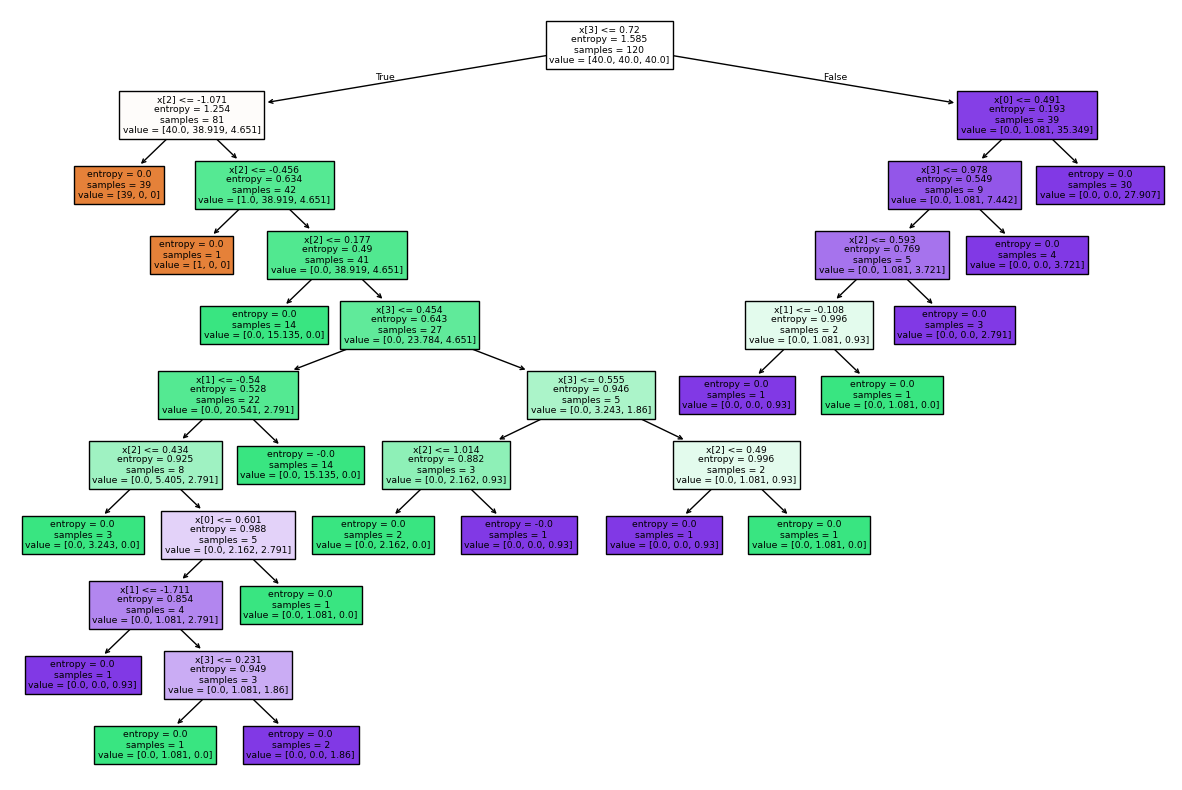

In [235]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(best_model["model"],filled=True)
